# Sesión 1: People Analytics en GCP — De Datos Crudos a Arquitectura Profesional

## Módulo 1: Contexto Real de Analítica de Datos en People Analytics
## Módulo 2: Arquitectura Actual de Datos en Google Cloud Platform

### Objetivos de este notebook
1. Configurar un entorno híbrido (Vertex AI Workbench / local)
2. Crear datasets en BigQuery con arquitectura Medallion (Bronze → Silver → Gold)
3. Ingestar datos reales anonimizados de Personio en la capa Bronze
4. Transformar y limpiar datos en la capa Silver (tipado, deduplicación, normalización)
5. Construir métricas de People Analytics en la capa Gold
6. Analizar sesgos, equidad salarial y riesgos de re-identificación con datos reales

**Datos**: Datasets anonimizados reales de un HRIS (Personio) — empleados, histórico salarial y nómina mensual.

---
## 1. Setup del entorno híbrido

Este notebook funciona tanto en **Vertex AI Workbench** como en un **entorno local**.
La detección es automática: en Vertex AI se usa Application Default Credentials (ADC),
en local se carga un service account desde `.env`.

In [1]:
# Instalar dependencias (descomentar en primera ejecución)
# !pip install google-cloud-bigquery google-cloud-storage pandas pyarrow db-dtypes python-dotenv matplotlib seaborn scikit-learn scipy

In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.cloud import bigquery
from google.api_core.exceptions import NotFound, Conflict
import warnings
warnings.filterwarnings('ignore')

# --- Configuración visual ---
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 11

# --- Detección de entorno ---
IN_VERTEX_AI = any([
    os.environ.get("DL_ANACONDA_HOME"),
    os.path.exists("/opt/deeplearning/metadata"),
    os.environ.get("GOOGLE_CLOUD_PROJECT"),
])

if IN_VERTEX_AI:
    PROJECT_ID = os.environ.get("GOOGLE_CLOUD_PROJECT", "people-analytics-formacion")
    client = bigquery.Client(project=PROJECT_ID)
    print(f"Entorno: Vertex AI Workbench (ADC)")
else:
    from dotenv import load_dotenv
    from google.oauth2 import service_account
    load_dotenv()
    PROJECT_ID = os.environ.get("GCP_PROJECT_ID", "people-analytics-formacion")
    creds_path = os.environ.get("GOOGLE_APPLICATION_CREDENTIALS", "service-account.json")
    if os.path.exists(creds_path):
        credentials = service_account.Credentials.from_service_account_file(creds_path)
        client = bigquery.Client(project=PROJECT_ID, credentials=credentials)
    else:
        client = bigquery.Client(project=PROJECT_ID)
    print(f"Entorno: Local")

REGION = "europe-southwest1"

print(f"Proyecto: {PROJECT_ID}")
print(f"Region: {REGION}")
print(f"Cliente BQ: {client.project}")

Entorno: Local
Proyecto: project-9176af0b-ecb3-4050-859
Region: europe-southwest1
Cliente BQ: project-9176af0b-ecb3-4050-859


---
## 2. Arquitectura Medallion — Definición de datasets

Organizamos BigQuery en capas siguiendo el patrón **Bronze → Silver → Gold**:

```
proyecto/
├── bronze_personio          # Raw: datos tal cual llegan del HRIS
├── silver_personio          # Clean: tipado, validado, normalizado  
├── gold_people_analytics    # Business: métricas listas para consumo
└── ml_features              # ML: feature store para Vertex AI / BQML
```

Cada dataset es accesible tanto desde BigQuery como desde Vertex AI, Looker Studio o Connected Sheets.

In [3]:
# --- Crear datasets (idempotente) ---
DATASETS = {
    "bronze_personio": "Capa Bronze — datos crudos de Personio sin transformar",
    "silver_personio": "Capa Silver — datos limpios, tipados y normalizados",
    "gold_people_analytics": "Capa Gold — métricas de negocio para People Analytics",
    "ml_features": "Feature store para modelos de ML (Vertex AI / BQML)",
}

for dataset_id, description in DATASETS.items():
    dataset_ref = f"{PROJECT_ID}.{dataset_id}"
    dataset = bigquery.Dataset(dataset_ref)
    dataset.location = REGION
    dataset.description = description
    try:
        client.create_dataset(dataset)
        print(f"  Creado: {dataset_id}")
    except Conflict:
        print(f"  Existe: {dataset_id}")

print(f"\nDatasets disponibles en {PROJECT_ID}:")
for ds in client.list_datasets():
    print(f"  - {ds.dataset_id}")

  Existe: bronze_personio
  Existe: silver_personio
  Existe: gold_people_analytics
  Existe: ml_features

Datasets disponibles en project-9176af0b-ecb3-4050-859:
  - bronze_personio
  - gold_people_analytics
  - ml_features
  - silver_personio


---
## 3. Capa Bronze — Ingesta de datos crudos

Cargamos los 3 CSVs anonimizados directamente a BigQuery **sin transformar**.
La capa Bronze es un espejo fiel de los datos de origen.

| Tabla | Origen | Filas | Columnas | Granularidad |
|-------|--------|-------|----------|--------------|
| `raw_employee_data` | Personio API (snapshot) | ~209 | 117 | 1 fila por empleado |
| `raw_employee_history` | Personio histórico | ~1.189 | 79 | 1 fila por empleado/mes |
| `raw_gross_salary` | Nómina mensual | ~994 | 109 | 1 fila por empleado/mes |

In [4]:
# --- Cargar CSVs ---
DATA_DIR = os.path.join(os.path.dirname(os.getcwd()), "data", "documentacion")
if not os.path.exists(DATA_DIR):
    DATA_DIR = os.path.join(os.getcwd(), "data", "documentacion")
if not os.path.exists(DATA_DIR):
    DATA_DIR = os.path.join(os.getcwd(), "..", "data", "documentacion")

print(f"Directorio de datos: {DATA_DIR}")

df_employee = pd.read_csv(os.path.join(DATA_DIR, "personio_data_v2_anon.csv"))
df_history = pd.read_csv(os.path.join(DATA_DIR, "personio_history_v2_anon.csv"))
df_salary = pd.read_csv(os.path.join(DATA_DIR, "gross_salary_v2_anon.csv"))

print(f"\nDatos cargados:")
print(f"  employee_data:    {df_employee.shape[0]:>5} filas x {df_employee.shape[1]:>3} columnas")
print(f"  employee_history: {df_history.shape[0]:>5} filas x {df_history.shape[1]:>3} columnas")
print(f"  gross_salary:     {df_salary.shape[0]:>5} filas x {df_salary.shape[1]:>3} columnas")

Directorio de datos: /Users/main/Desktop/curso-vertexai/data/documentacion

Datos cargados:
  employee_data:      209 filas x 117 columnas
  employee_history:  1189 filas x  79 columnas
  gross_salary:       994 filas x 109 columnas


In [5]:
# --- Vista rápida de cada tabla ---
print("=" * 70)
print("EMPLOYEE DATA — Snapshot actual de Personio")
print("=" * 70)
print(f"Empleados únicos: {df_employee['employee_code'].nunique()}")
print(f"Status: {df_employee['status'].value_counts().to_dict()}")
print(f"Departamentos: {df_employee['department'].nunique()} -> {df_employee['department'].value_counts().to_dict()}")
print(f"Países: {df_employee['country'].nunique()} -> {df_employee['country'].value_counts().head(5).to_dict()}")
print(f"Monedas: {df_employee['gross_salary_currency'].value_counts().to_dict()}")
print(f"Columnas 100% nulas: {(df_employee.isnull().sum() == len(df_employee)).sum()}")

print(f"\n{'=' * 70}")
print("EMPLOYEE HISTORY — Snapshots mensuales de compensación")
print("=" * 70)
print(f"Empleados únicos: {df_history['employee_code'].nunique()}")
print(f"Rango temporal: {df_history['year'].min()}-{df_history['month'].min():02d} a {df_history['year'].max()}-{df_history['month'].max():02d}")
print(f"FTE rango: {df_history['fte'].min()} - {df_history['fte'].max()}")
print(f"HC status: {df_history['hc_status'].value_counts().to_dict()}")

print(f"\n{'=' * 70}")
print("GROSS SALARY — Nómina mensual detallada")
print("=" * 70)
print(f"Empleados únicos: {df_salary['employee_code'].nunique()}")
print(f"Entidades legales: {df_salary['legal_entity'].nunique()} -> {df_salary['legal_entity'].value_counts().head(5).to_dict()}")
print(f"Monedas: {df_salary['local_currency_LC'].value_counts().to_dict()}")
print(f"Coste empresa medio mensual (LC): {df_salary['total_company_cost_LC'].mean():,.0f}")

EMPLOYEE DATA — Snapshot actual de Personio
Empleados únicos: 209
Status: {'active': 121, 'inactive': 83, 'onboarding': 5}
Departamentos: 2 -> {'People': 164, 'PR & Communication': 45}
Países: 12 -> {'Spain': 172, 'United States': 12, 'Mexico': 7, 'United Kingdom': 6, 'Australia': 3}
Monedas: {'EUR': 172, 'USD': 11, 'MXN': 7, 'GBP': 6, 'AUD': 3, 'BRL': 3, 'INR': 1, 'ARS': 1, 'JPY': 1}
Columnas 100% nulas: 23

EMPLOYEE HISTORY — Snapshots mensuales de compensación
Empleados únicos: 136
Rango temporal: 2025-01 a 2025-12
FTE rango: 0.03 - 1.0
HC status: {'ALTA': 1163, 'BAJA': 26}

GROSS SALARY — Nómina mensual detallada
Empleados únicos: 131
Entidades legales: 9 -> {'KZEMOS TECHNOLOGIES': 830, 'FEVER LABS INC': 65, 'KZEMOS UK': 26, 'KZEMOS AUSTRALIA PTY LTD': 24, 'KZEMOS S.A. de C.V.': 14}
Monedas: {'EUR': 851, 'USD': 65, 'GBP': 26, 'AUD': 24, 'MXN': 14, 'BRL': 12, 'JPY': 2}
Coste empresa medio mensual (LC): 5,966


In [6]:
# --- Subir a Bronze en BigQuery ---
BRONZE = "bronze_personio"

bronze_tables = {
    "raw_employee_data": df_employee,
    "raw_employee_history": df_history,
    "raw_gross_salary": df_salary,
}

for table_name, df in bronze_tables.items():
    table_id = f"{PROJECT_ID}.{BRONZE}.{table_name}"
    job_config = bigquery.LoadJobConfig(
        write_disposition=bigquery.WriteDisposition.WRITE_TRUNCATE,
        autodetect=True,
    )
    job = client.load_table_from_dataframe(df, table_id, job_config=job_config)
    job.result()
    table = client.get_table(table_id)
    print(f"  {BRONZE}.{table_name}: {table.num_rows} filas, {len(table.schema)} columnas")

print(f"\nCapa Bronze cargada en BigQuery")

  bronze_personio.raw_employee_data: 209 filas, 117 columnas
  bronze_personio.raw_employee_history: 1189 filas, 79 columnas
  bronze_personio.raw_gross_salary: 994 filas, 109 columnas

Capa Bronze cargada en BigQuery


---
## 4. Capa Silver — Transformación y limpieza

Desde BigQuery SQL creamos las tablas Silver. Aquí aplicamos:
- Eliminación de columnas 100% nulas
- Tipado correcto (fechas, numéricos, booleanos)
- Normalización de valores inconsistentes (género, país)
- Estructura dimensional: `dim_employee` + `fact_salary_history` + `fact_payroll_monthly`

In [7]:
SILVER = "silver_personio"

# --- dim_employee: dimensión de empleado (snapshot actual, limpio) ---
sql_dim_employee = f"""
CREATE OR REPLACE TABLE `{PROJECT_ID}.{SILVER}.dim_employee` AS
SELECT
    employee_code,
    email,
    first_name,
    last_name,
    LOWER(TRIM(gender)) AS gender,
    SAFE.PARSE_DATE('%Y-%m-%d', hire_date) AS hire_date,
    SAFE.PARSE_DATE('%Y-%m-%d', termination_date) AS termination_date,
    COALESCE(termination_type, 'active') AS termination_type,
    termination_reason,
    status,
    department,
    team,
    subteam,
    position,
    role,
    office,
    subcompany AS legal_entity,
    country,
    city,
    supervisor,
    type_of_contract,
    nationality,
    studies,
    working_schedule,

    -- Compensación actual
    CAST(gross_salary AS FLOAT64) AS gross_salary_annual,
    gross_salary_currency,
    CAST(previous_gross_salary AS FLOAT64) AS previous_gross_salary_annual,
    CASE
        WHEN SAFE_CAST(bonus AS FLOAT64) IS NOT NULL THEN SAFE_CAST(bonus AS FLOAT64)
        ELSE NULL
    END AS bonus_pct,
    CASE
        WHEN SAFE_CAST(bonus AS FLOAT64) IS NULL AND bonus IS NOT NULL THEN bonus
        ELSE NULL
    END AS bonus_description,
    CAST(total_number_of_stock_options AS INT64) AS stock_options,
    SAFE.PARSE_DATE('%Y-%m-%d', last_salary_update) AS last_salary_update,
    salary_type,
    payroll_payment_frequency,
    CAST(weekly_hours AS INT64) AS weekly_hours,

    -- Clasificación / bandas
    global_job_id,
    band,
    CAST(global_grade AS FLOAT64) AS global_grade,
    aon_grade,
    CAST(tier AS FLOAT64) AS tier,
    unique_position,
    area,
    grupo,
    nivel,
    cost_center,

    -- Cambios salariales
    change_of_salary_reason,
    change_of_salary_window,
    variable_payment_frequency,

    -- Metadata
    SAFE.PARSE_DATE('%Y-%m-%d', created_date) AS snapshot_date,
    SAFE.PARSE_DATE('%Y-%m-%d', probation_period_end) AS probation_end,

    -- Campos derivados
    DATE_DIFF(
        COALESCE(SAFE.PARSE_DATE('%Y-%m-%d', termination_date), CURRENT_DATE()),
        SAFE.PARSE_DATE('%Y-%m-%d', hire_date),
        MONTH
    ) AS tenure_months,
    CASE WHEN status = 'active' THEN TRUE ELSE FALSE END AS is_active,

FROM `{PROJECT_ID}.{BRONZE}.raw_employee_data`
"""

client.query(sql_dim_employee).result()
table = client.get_table(f"{PROJECT_ID}.{SILVER}.dim_employee")
print(f"dim_employee: {table.num_rows} filas, {len(table.schema)} columnas")

dim_employee: 209 filas, 51 columnas


In [8]:
# --- fact_salary_history: histórico salarial mensual ---
sql_fact_history = f"""
CREATE OR REPLACE TABLE `{PROJECT_ID}.{SILVER}.fact_salary_history`
PARTITION BY snapshot_date
CLUSTER BY employee_code, department
AS
SELECT
    employee_code,
    SAFE.PARSE_DATE('%Y-%m-%d', hire_date) AS hire_date,
    SAFE.PARSE_DATE('%Y-%m-%d', termination_date) AS termination_date,
    department,
    team,
    subteam,
    position,
    office,
    legal_entity,
    status,
    hc_status,
    global_job_id,

    -- Temporal
    CAST(year AS INT64) AS year,
    CAST(month AS INT64) AS month,
    SAFE.PARSE_DATE('%Y-%m-%d', closed_date) AS snapshot_date,

    -- Compensación en moneda local
    CAST(gross_salary AS FLOAT64) AS gross_salary_monthly_lc,
    CAST(bonus_absolute AS FLOAT64) AS bonus_monthly_lc,
    gross_salary_currency AS currency,
    CAST(previous_gross_salary AS FLOAT64) AS previous_gross_salary_lc,

    -- Compensación en USD (FX actual)
    CAST(fixed_usd_fx_cm AS FLOAT64) AS fixed_usd_current,
    CAST(bonus_usd_fx_cm AS FLOAT64) AS bonus_usd_current,
    CAST(ttc_usd_fx_cm AS FLOAT64) AS ttc_usd_current,
    CAST(ss_usd_fx_cm AS FLOAT64) AS ss_usd_current,

    -- Compensación en USD (FX presupuesto)
    CAST(fixed_usd_fx_budget AS FLOAT64) AS fixed_usd_budget,
    CAST(bonus_usd_fx_budget AS FLOAT64) AS bonus_usd_budget,
    CAST(ttc_usd_fx_budget AS FLOAT64) AS ttc_usd_budget,
    CAST(ss_usd_fx_budget AS FLOAT64) AS ss_usd_budget,

    -- FX y FTE
    CAST(fx_cm AS FLOAT64) AS fx_rate_current,
    CAST(fx_budget AS FLOAT64) AS fx_rate_budget,
    CAST(fte AS FLOAT64) AS fte,
    CAST(ss_percentage AS FLOAT64) AS ss_percentage,

    -- Cambios
    change_of_salary_reason,
    change_of_salary_window,

FROM `{PROJECT_ID}.{BRONZE}.raw_employee_history`
"""

client.query(sql_fact_history).result()
table = client.get_table(f"{PROJECT_ID}.{SILVER}.fact_salary_history")
print(f"fact_salary_history: {table.num_rows} filas, {len(table.schema)} columnas")
print(f"  Particionada por: snapshot_date")
print(f"  Clustered por: employee_code, department")

fact_salary_history: 1189 filas, 33 columnas
  Particionada por: snapshot_date
  Clustered por: employee_code, department


In [9]:
# --- fact_payroll_monthly: nómina mensual con componentes ---
sql_fact_payroll = f"""
CREATE OR REPLACE TABLE `{PROJECT_ID}.{SILVER}.fact_payroll_monthly`
PARTITION BY payroll_date
CLUSTER BY employee_code, legal_entity, country
AS
SELECT
    employee_code,
    employee_name,
    INITCAP(LOWER(gender)) AS gender,
    department,
    team,
    subteam,
    legal_entity,
    position,
    country,
    local_currency_LC AS currency,

    CAST(year AS INT64) AS year,
    CAST(month AS INT64) AS month,
    DATE(CAST(year AS INT64), CAST(month AS INT64), 1) AS payroll_date,

    -- Componentes en moneda local
    CAST(fixed_salary_LC AS FLOAT64) AS fixed_salary_lc,
    CAST(comms_bonuses_LC AS FLOAT64) AS bonuses_lc,
    CAST(referral_bonus_LC AS FLOAT64) AS referral_bonus_lc,
    CAST(extra_pay_fixed_LC AS FLOAT64) AS extra_pay_fixed_lc,
    CAST(extra_pay_other_LC AS FLOAT64) AS extra_pay_other_lc,
    CAST(vacation_pay_LC AS FLOAT64) AS vacation_pay_lc,
    CAST(back_pay_LC AS FLOAT64) AS back_pay_lc,
    CAST(unused_holidays_LC AS FLOAT64) AS unused_holidays_lc,
    CAST(severance_payment_LC AS FLOAT64) AS severance_lc,
    CAST(total_severance_LC AS FLOAT64) AS total_severance_lc,

    -- Beneficios
    CAST(health_insurance_LC AS FLOAT64) AS health_insurance_lc,
    CAST(gympass_LC AS FLOAT64) AS gympass_lc,
    CAST(travel_tickets_LC AS FLOAT64) AS travel_tickets_lc,
    CAST(meal_tickets_LC AS FLOAT64) AS meal_tickets_lc,
    CAST(pension_plan_er_contribution_LC AS FLOAT64) AS pension_contribution_lc,
    CAST(executed_stock_options_LC AS FLOAT64) AS stock_options_lc,

    -- Totales
    CAST(total_gross_salary_LC AS FLOAT64) AS total_gross_lc,
    CAST(reporting_gross_salary_LC AS FLOAT64) AS reporting_gross_lc,
    CAST(ss_employer_LC AS FLOAT64) AS ss_employer_lc,
    CAST(total_company_cost_LC AS FLOAT64) AS total_company_cost_lc,

    -- Totales en USD
    CAST(total_gross_salary_USD AS FLOAT64) AS total_gross_usd,
    CAST(reporting_gross_salary_USD AS FLOAT64) AS reporting_gross_usd,
    CAST(ss_employer_USD AS FLOAT64) AS ss_employer_usd,
    CAST(total_company_cost_USD AS FLOAT64) AS total_company_cost_usd,

    -- FX y FTE
    CAST(fx_to_apply AS FLOAT64) AS fx_rate,
    CAST(fte AS FLOAT64) AS fte,
    SAFE.PARSE_DATE('%Y-%m-%d', hire_date) AS hire_date,
    SAFE.PARSE_DATE('%Y-%m-%d', termination_date) AS termination_date,

FROM `{PROJECT_ID}.{BRONZE}.raw_gross_salary`
"""

client.query(sql_fact_payroll).result()
table = client.get_table(f"{PROJECT_ID}.{SILVER}.fact_payroll_monthly")
print(f"fact_payroll_monthly: {table.num_rows} filas, {len(table.schema)} columnas")
print(f"  Particionada por: payroll_date")
print(f"  Clustered por: employee_code, legal_entity, country")

fact_payroll_monthly: 994 filas, 41 columnas
  Particionada por: payroll_date
  Clustered por: employee_code, legal_entity, country


In [10]:
# --- Validación de la capa Silver ---
print("VALIDACIÓN DE CAPA SILVER")
print("=" * 60)

for table_name in ["dim_employee", "fact_salary_history", "fact_payroll_monthly"]:
    t = client.get_table(f"{PROJECT_ID}.{SILVER}.{table_name}")
    print(f"\n  {table_name}: {t.num_rows} filas, {len(t.schema)} columnas")

# Validación cruzada: ¿cuántos employee_codes hay en las 3 tablas?
sql_overlap = f"""
SELECT
    (SELECT COUNT(DISTINCT employee_code) FROM `{PROJECT_ID}.{SILVER}.dim_employee`) AS dim_codes,
    (SELECT COUNT(DISTINCT employee_code) FROM `{PROJECT_ID}.{SILVER}.fact_salary_history`) AS history_codes,
    (SELECT COUNT(DISTINCT employee_code) FROM `{PROJECT_ID}.{SILVER}.fact_payroll_monthly`) AS payroll_codes,
    (SELECT COUNT(DISTINCT e.employee_code)
     FROM `{PROJECT_ID}.{SILVER}.dim_employee` e
     INNER JOIN `{PROJECT_ID}.{SILVER}.fact_salary_history` h ON e.employee_code = h.employee_code
     INNER JOIN `{PROJECT_ID}.{SILVER}.fact_payroll_monthly` p ON e.employee_code = p.employee_code
    ) AS in_all_three
"""
result = client.query(sql_overlap).to_dataframe()
print(f"\nCobertura de employee_code:")
print(f"  dim_employee:        {result['dim_codes'].iloc[0]}")
print(f"  fact_salary_history: {result['history_codes'].iloc[0]}")
print(f"  fact_payroll:        {result['payroll_codes'].iloc[0]}")
print(f"  En las 3 tablas:     {result['in_all_three'].iloc[0]}")

VALIDACIÓN DE CAPA SILVER

  dim_employee: 209 filas, 51 columnas

  fact_salary_history: 1189 filas, 33 columnas

  fact_payroll_monthly: 994 filas, 41 columnas

Cobertura de employee_code:
  dim_employee:        209
  fact_salary_history: 136
  fact_payroll:        131
  En las 3 tablas:     130


---
## 5. Capa Gold — Métricas de People Analytics

Construimos vistas y tablas analíticas listas para consumo por RRHH, Looker Studio o Vertex AI.

In [11]:
GOLD = "gold_people_analytics"

# --- Headcount mensual: HC y FTE por mes/departamento/entidad ---
sql_headcount = f"""
CREATE OR REPLACE TABLE `{PROJECT_ID}.{GOLD}.headcount_monthly` AS
SELECT
    snapshot_date,
    year,
    month,
    department,
    team,
    legal_entity,
    office,
    hc_status,
    COUNT(DISTINCT employee_code) AS headcount,
    SUM(fte) AS total_fte,
    AVG(fixed_usd_budget) AS avg_fixed_usd,
    SUM(fixed_usd_budget) AS total_fixed_usd,
    SUM(ttc_usd_budget) AS total_ttc_usd,
    SUM(ss_usd_budget) AS total_ss_usd,
FROM `{PROJECT_ID}.{SILVER}.fact_salary_history`
GROUP BY ALL
"""
client.query(sql_headcount).result()
print("headcount_monthly creada")

headcount_monthly creada


In [12]:
# --- Análisis de compensación: equity y compa-ratio ---
sql_compensation = f"""
CREATE OR REPLACE TABLE `{PROJECT_ID}.{GOLD}.compensation_analysis` AS
WITH salary_bands AS (
    SELECT
        band,
        gender,
        AVG(gross_salary_annual) AS avg_salary,
        PERCENTILE_CONT(gross_salary_annual, 0.5) OVER (PARTITION BY band) AS band_median,
    FROM `{PROJECT_ID}.{SILVER}.dim_employee`
    WHERE is_active AND band IS NOT NULL AND gender IS NOT NULL
    GROUP BY band, gender, gross_salary_annual
)
SELECT
    e.employee_code,
    e.gender,
    e.department,
    e.team,
    e.position,
    e.band,
    e.global_grade,
    e.tier,
    e.country,
    e.legal_entity,
    e.tenure_months,
    e.gross_salary_annual,
    e.gross_salary_currency,
    e.previous_gross_salary_annual,
    e.stock_options,
    e.change_of_salary_reason,

    -- Compa-ratio: salario vs mediana del band
    band_stats.band_median,
    SAFE_DIVIDE(e.gross_salary_annual, band_stats.band_median) AS compa_ratio,

    -- Variación salarial
    SAFE_DIVIDE(
        e.gross_salary_annual - e.previous_gross_salary_annual,
        NULLIF(e.previous_gross_salary_annual, 0)
    ) AS salary_change_pct,

FROM `{PROJECT_ID}.{SILVER}.dim_employee` e
LEFT JOIN (
    SELECT band, APPROX_QUANTILES(gross_salary_annual, 2)[OFFSET(1)] AS band_median
    FROM `{PROJECT_ID}.{SILVER}.dim_employee`
    WHERE is_active AND band IS NOT NULL
    GROUP BY band
) band_stats ON e.band = band_stats.band
WHERE e.is_active
"""
client.query(sql_compensation).result()
print("compensation_analysis creada")

compensation_analysis creada


In [13]:
# --- Métricas de rotación ---
sql_turnover = f"""
CREATE OR REPLACE TABLE `{PROJECT_ID}.{GOLD}.turnover_metrics` AS
SELECT
    employee_code,
    gender,
    department,
    team,
    position,
    band,
    country,
    legal_entity,
    hire_date,
    termination_date,
    termination_type,
    termination_reason,
    tenure_months,
    gross_salary_annual,
    gross_salary_currency,
    is_active,

    CASE
        WHEN termination_type = 'employee-quit' THEN 'Voluntaria'
        WHEN termination_type = 'fired' THEN 'Involuntaria'
        WHEN termination_type = 'contract-expired' THEN 'Fin contrato'
        ELSE 'Activo'
    END AS exit_category,

    CASE
        WHEN tenure_months <= 6 THEN '0-6 meses'
        WHEN tenure_months <= 12 THEN '6-12 meses'
        WHEN tenure_months <= 24 THEN '1-2 años'
        WHEN tenure_months <= 48 THEN '2-4 años'
        ELSE '4+ años'
    END AS tenure_bucket,

FROM `{PROJECT_ID}.{SILVER}.dim_employee`
"""
client.query(sql_turnover).result()
print("turnover_metrics creada")

turnover_metrics creada


In [14]:
# --- Resumen de la capa Gold ---
print("CAPA GOLD — Métricas de People Analytics")
print("=" * 60)
for table_name in ["headcount_monthly", "compensation_analysis", "turnover_metrics"]:
    t = client.get_table(f"{PROJECT_ID}.{GOLD}.{table_name}")
    print(f"  {table_name}: {t.num_rows} filas, {len(t.schema)} columnas")

CAPA GOLD — Métricas de People Analytics
  headcount_monthly: 317 filas, 14 columnas
  compensation_analysis: 121 filas, 19 columnas
  turnover_metrics: 209 filas, 18 columnas


---
## 6. Análisis de People Analytics — Sesgo, equidad y riesgos

Ahora trabajamos desde la capa Gold. Todo el análisis se hace consultando BigQuery, como en un entorno real.

### 6.1 Brecha salarial de género — Análisis controlado

No basta con comparar medias brutas. Hay que controlar por **band**, **tenure** y **country** para aislar el efecto del género.

In [15]:
# --- Brecha bruta ---
sql_gap_bruta = f"""
SELECT
    gender,
    COUNT(*) AS n,
    AVG(gross_salary_annual) AS avg_salary,
    APPROX_QUANTILES(gross_salary_annual, 2)[OFFSET(1)] AS median_salary
FROM `{PROJECT_ID}.{GOLD}.compensation_analysis`
WHERE gender IS NOT NULL
GROUP BY gender
"""
df_gap = client.query(sql_gap_bruta).to_dataframe()

print("BRECHA SALARIAL BRUTA")
print("=" * 50)
for _, row in df_gap.iterrows():
    print(f"  {row['gender']:>8}: n={row['n']:>3}  media={row['avg_salary']:>10,.0f}  mediana={row['median_salary']:>10,.0f}")

if len(df_gap) == 2:
    sal_m = df_gap[df_gap['gender'] == 'male']['avg_salary'].iloc[0]
    sal_f = df_gap[df_gap['gender'] == 'female']['avg_salary'].iloc[0]
    brecha = (sal_m - sal_f) / sal_m * 100
    print(f"\n  Brecha bruta: {brecha:.1f}% {'a favor de hombres' if brecha > 0 else 'a favor de mujeres'}")
    print(f"  (Sin controlar por band, tenure ni país — no es concluyente)")

BRECHA SALARIAL BRUTA
    female: n= 91  media=   392,871  mediana=    35,239
      male: n= 30  media=    48,395  mediana=    41,189

  Brecha bruta: -711.8% a favor de mujeres
  (Sin controlar por band, tenure ni país — no es concluyente)


BRECHA SALARIAL POR BAND (controlada)
gender        female           male  brecha_%  n_male  n_female
band                                                           
E1               NaN  101173.720000       NaN       1      <NA>
E2               NaN   93030.560000       NaN       1      <NA>
M2      55203.461429   68504.434000      19.4       5         7
M3      81433.000000   78058.310000      -4.3       1         1
P1      28003.180000            NaN       NaN    <NA>         1
P2      42638.925294   32809.046364     -30.0      11        51
P3      51487.674000   42070.488333     -22.4       6        10
U3      82488.500000            NaN       NaN    <NA>         1
W2               NaN    7565.180000       NaN       1      <NA>


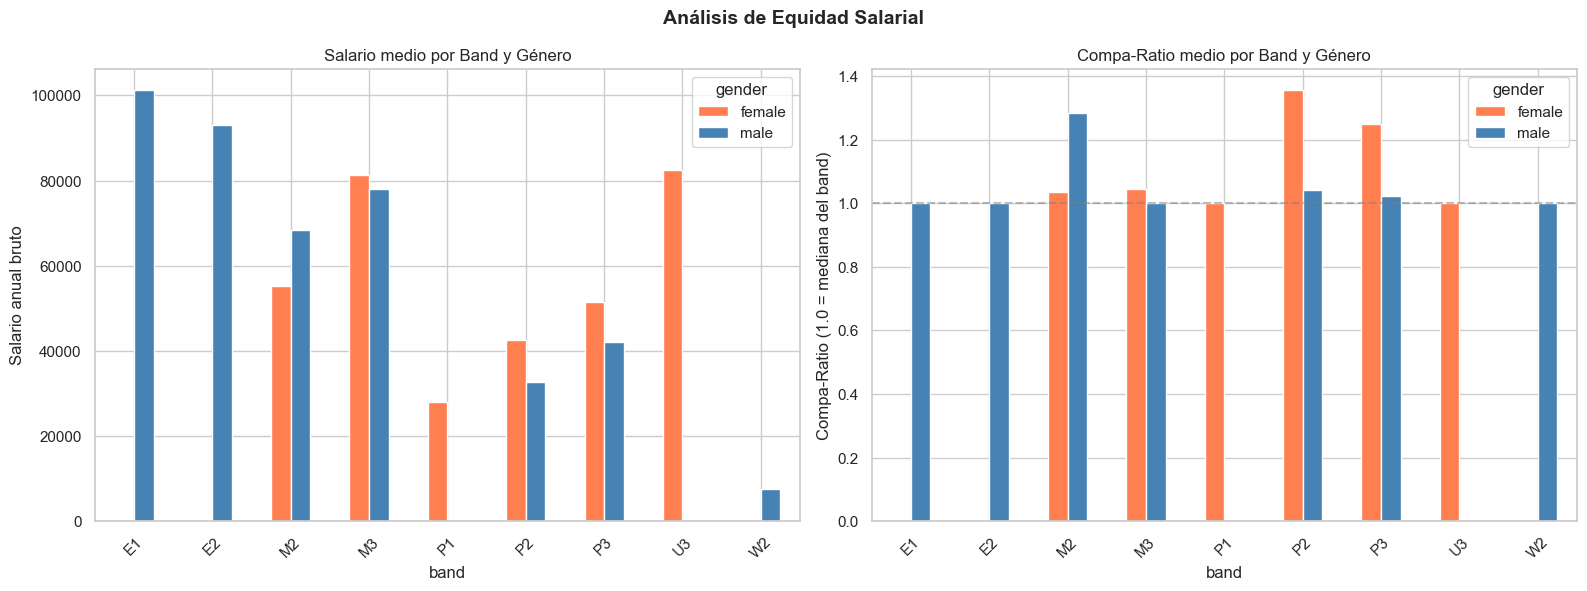

In [16]:
# --- Brecha controlada por band ---
sql_gap_band = f"""
SELECT
    band,
    gender,
    COUNT(*) AS n,
    AVG(gross_salary_annual) AS avg_salary,
    AVG(compa_ratio) AS avg_compa_ratio
FROM `{PROJECT_ID}.{GOLD}.compensation_analysis`
WHERE gender IS NOT NULL AND band IS NOT NULL
GROUP BY band, gender
ORDER BY band, gender
"""
df_band = client.query(sql_gap_band).to_dataframe()

print("BRECHA SALARIAL POR BAND (controlada)")
print("=" * 70)

pivot = df_band.pivot_table(index='band', columns='gender', values='avg_salary')
if 'male' in pivot.columns and 'female' in pivot.columns:
    pivot['brecha_%'] = ((pivot['male'] - pivot['female']) / pivot['male'] * 100).round(1)
    pivot['n_male'] = df_band[df_band['gender']=='male'].set_index('band')['n']
    pivot['n_female'] = df_band[df_band['gender']=='female'].set_index('band')['n']
    print(pivot.to_string())

# Visualización
if not df_band.empty:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Salario medio por band y género
    pivot_plot = df_band.pivot_table(index='band', columns='gender', values='avg_salary')
    pivot_plot.plot(kind='bar', ax=axes[0], color={'male': 'steelblue', 'female': 'coral'})
    axes[0].set_title('Salario medio por Band y Género')
    axes[0].set_ylabel('Salario anual bruto')
    axes[0].tick_params(axis='x', rotation=45)

    # Compa-ratio por band y género
    compa = df_band.pivot_table(index='band', columns='gender', values='avg_compa_ratio')
    compa.plot(kind='bar', ax=axes[1], color={'male': 'steelblue', 'female': 'coral'})
    axes[1].set_title('Compa-Ratio medio por Band y Género')
    axes[1].set_ylabel('Compa-Ratio (1.0 = mediana del band)')
    axes[1].axhline(y=1.0, color='gray', linestyle='--', alpha=0.5)
    axes[1].tick_params(axis='x', rotation=45)

    plt.suptitle('Análisis de Equidad Salarial', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

### 6.2 Distribución organizacional y concentración de género

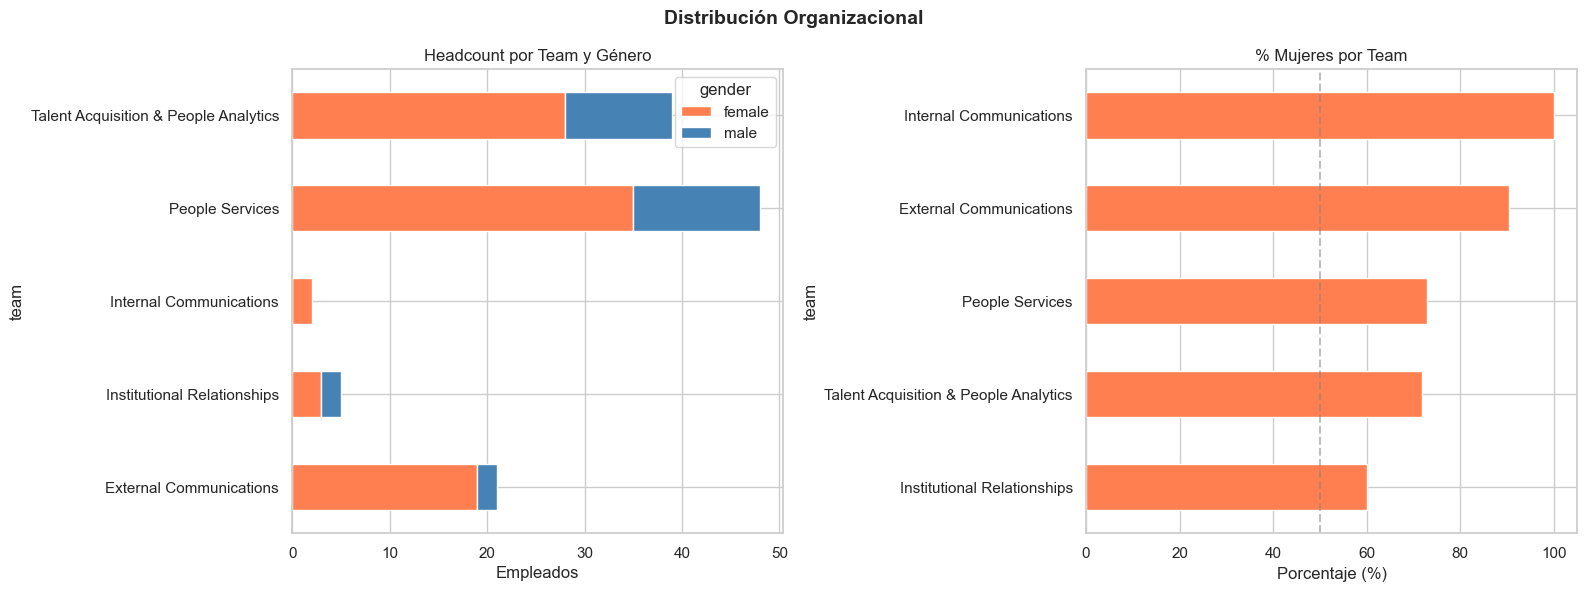

In [17]:
# --- Distribución por team y género ---
sql_org = f"""
SELECT
    team,
    gender,
    COUNT(*) AS n,
    AVG(tenure_months) AS avg_tenure,
    AVG(gross_salary_annual) AS avg_salary
FROM `{PROJECT_ID}.{SILVER}.dim_employee`
WHERE is_active AND team IS NOT NULL AND gender IS NOT NULL
GROUP BY team, gender
ORDER BY team, gender
"""
df_org = client.query(sql_org).to_dataframe()

if not df_org.empty:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Headcount por team y género
    hc_pivot = df_org.pivot_table(index='team', columns='gender', values='n', fill_value=0)
    hc_pivot.plot(kind='barh', stacked=True, ax=axes[0], color={'male': 'steelblue', 'female': 'coral'})
    axes[0].set_title('Headcount por Team y Género')
    axes[0].set_xlabel('Empleados')

    # % femenino por team
    pct = hc_pivot.copy()
    if 'female' in pct.columns and 'male' in pct.columns:
        pct['pct_female'] = pct['female'] / (pct['female'] + pct['male']) * 100
        pct['pct_female'].sort_values().plot(kind='barh', ax=axes[1], color='coral')
        axes[1].set_title('% Mujeres por Team')
        axes[1].set_xlabel('Porcentaje (%)')
        axes[1].axvline(x=50, color='gray', linestyle='--', alpha=0.5)

    plt.suptitle('Distribución Organizacional', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

### 6.3 Análisis de rotación con datos reales

In [18]:
# --- Rotación real ---
sql_turnover_analysis = f"""
SELECT
    exit_category,
    COUNT(*) AS n,
    AVG(tenure_months) AS avg_tenure,
    AVG(gross_salary_annual) AS avg_salary
FROM `{PROJECT_ID}.{GOLD}.turnover_metrics`
GROUP BY exit_category
ORDER BY n DESC
"""
df_turnover = client.query(sql_turnover_analysis).to_dataframe()

total = df_turnover['n'].sum()
exits = df_turnover[df_turnover['exit_category'] != 'Activo']['n'].sum()

print("ANÁLISIS DE ROTACIÓN")
print("=" * 60)
print(f"Tasa de rotación total: {exits/total*100:.1f}%")
print(f"\nDesglose:")
for _, row in df_turnover.iterrows():
    print(f"  {row['exit_category']:>15}: {row['n']:>3} ({row['n']/total*100:>5.1f}%)  tenure={row['avg_tenure']:.0f} meses  salario={row['avg_salary']:,.0f}")

ANÁLISIS DE ROTACIÓN
Tasa de rotación total: 41.1%

Desglose:
           Activo: 123 ( 58.9%)  tenure=24 meses  salario=310,245
       Voluntaria:  61 ( 29.2%)  tenure=19 meses  salario=52,265
     Involuntaria:  18 (  8.6%)  tenure=15 meses  salario=80,415
     Fin contrato:   7 (  3.3%)  tenure=4 meses  salario=9,309


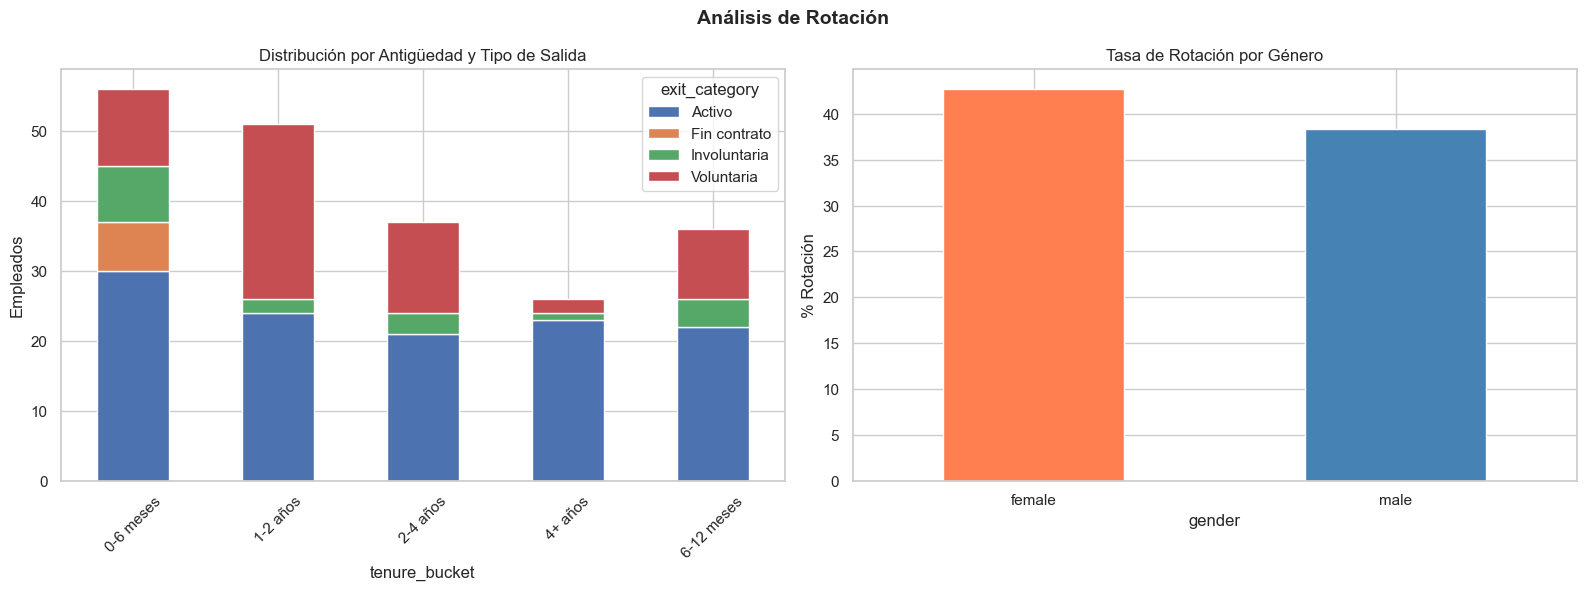

In [19]:
# --- Rotación por segmentos ---
sql_rot_segments = f"""
SELECT
    tenure_bucket,
    gender,
    exit_category,
    COUNT(*) AS n
FROM `{PROJECT_ID}.{GOLD}.turnover_metrics`
WHERE gender IS NOT NULL
GROUP BY tenure_bucket, gender, exit_category
ORDER BY tenure_bucket
"""
df_rot = client.query(sql_rot_segments).to_dataframe()

if not df_rot.empty:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Rotación por tenure bucket
    rot_by_tenure = df_rot.groupby(['tenure_bucket', 'exit_category'])['n'].sum().unstack(fill_value=0)
    rot_by_tenure.plot(kind='bar', stacked=True, ax=axes[0])
    axes[0].set_title('Distribución por Antigüedad y Tipo de Salida')
    axes[0].set_ylabel('Empleados')
    axes[0].tick_params(axis='x', rotation=45)

    # Rotación por género
    rot_gender = df_rot.groupby(['gender', 'exit_category'])['n'].sum().unstack(fill_value=0)
    exits_cols = [c for c in rot_gender.columns if c != 'Activo']
    if exits_cols:
        rot_gender['exit_rate'] = rot_gender[exits_cols].sum(axis=1) / rot_gender.sum(axis=1) * 100
        rot_gender['exit_rate'].plot(kind='bar', ax=axes[1], color=['coral', 'steelblue'])
        axes[1].set_title('Tasa de Rotación por Género')
        axes[1].set_ylabel('% Rotación')
        axes[1].tick_params(axis='x', rotation=0)

    plt.suptitle('Análisis de Rotación', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

### 6.4 Evolución del coste de plantilla (desde Silver)

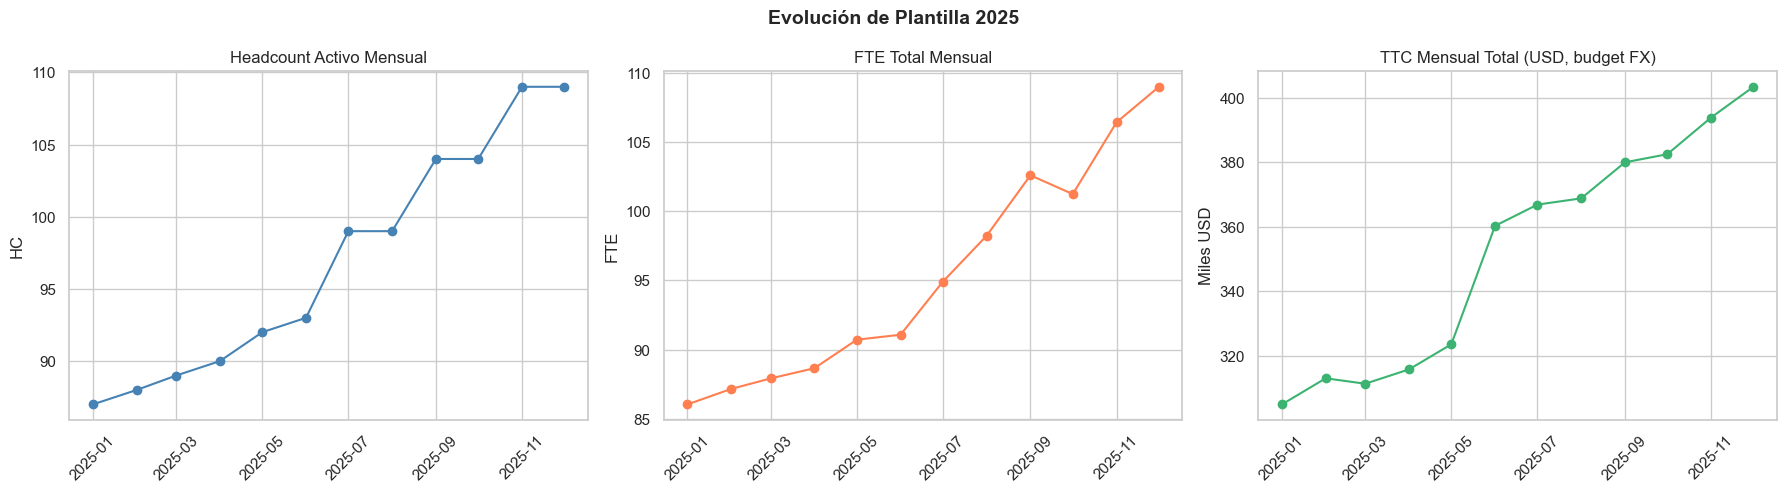

In [20]:
# --- Evolución mensual del coste ---
sql_cost_evolution = f"""
SELECT
    snapshot_date,
    hc_status,
    COUNT(DISTINCT employee_code) AS headcount,
    SUM(fte) AS total_fte,
    SUM(fixed_usd_budget) AS total_fixed_usd,
    SUM(ttc_usd_budget) AS total_ttc_usd,
    AVG(fixed_usd_budget) AS avg_fixed_usd
FROM `{PROJECT_ID}.{SILVER}.fact_salary_history`
WHERE hc_status = 'ALTA'
GROUP BY snapshot_date, hc_status
ORDER BY snapshot_date
"""
df_cost = client.query(sql_cost_evolution).to_dataframe()

if not df_cost.empty:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    axes[0].plot(df_cost['snapshot_date'], df_cost['headcount'], 'o-', color='steelblue')
    axes[0].set_title('Headcount Activo Mensual')
    axes[0].set_ylabel('HC')
    axes[0].tick_params(axis='x', rotation=45)

    axes[1].plot(df_cost['snapshot_date'], df_cost['total_fte'], 'o-', color='coral')
    axes[1].set_title('FTE Total Mensual')
    axes[1].set_ylabel('FTE')
    axes[1].tick_params(axis='x', rotation=45)

    axes[2].plot(df_cost['snapshot_date'], df_cost['total_ttc_usd'] / 1000, 'o-', color='mediumseagreen')
    axes[2].set_title('TTC Mensual Total (USD, budget FX)')
    axes[2].set_ylabel('Miles USD')
    axes[2].tick_params(axis='x', rotation=45)

    plt.suptitle('Evolución de Plantilla 2025', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

### 6.5 K-anonimidad — Riesgo de re-identificación con datos reales

Con solo 209 empleados y 117 columnas, el riesgo de re-identificación es **real y alto**.
Veamos cuántos empleados son únicos cruzando pocas variables.

In [21]:
# --- K-anonimidad sobre datos reales ---
sql_kanon = f"""
WITH grps AS (
    SELECT
        department, team, country, gender,
        COUNT(*) AS group_size
    FROM `{PROJECT_ID}.{SILVER}.dim_employee`
    WHERE is_active
    GROUP BY department, team, country, gender
)
SELECT
    COUNTIF(group_size = 1) AS groups_k1,
    COUNTIF(group_size = 2) AS groups_k2,
    COUNTIF(group_size BETWEEN 3 AND 5) AS groups_k3_5,
    COUNTIF(group_size > 5) AS groups_k5_plus,
    COUNT(*) AS total_groups,
    SUM(IF(group_size <= 2, group_size, 0)) AS personas_alto_riesgo,
    SUM(group_size) AS total_personas
FROM grps
"""
df_kanon = client.query(sql_kanon).to_dataframe()

print("K-ANONIMIDAD — Quasi-identificadores: department, team, country, gender")
print("=" * 70)
row = df_kanon.iloc[0]
print(f"  Grupos con 1 persona (re-identificable):  {row['groups_k1']}")
print(f"  Grupos con 2 personas:                    {row['groups_k2']}")
print(f"  Grupos con 3-5 personas:                  {row['groups_k3_5']}")
print(f"  Grupos con >5 personas:                   {row['groups_k5_plus']}")
print(f"  Total grupos:                             {row['total_groups']}")
print(f"\n  Personas en alto riesgo (k<=2):           {row['personas_alto_riesgo']} de {row['total_personas']} ({row['personas_alto_riesgo']/row['total_personas']*100:.1f}%)")
print(f"\n  Con datos reales de 209 empleados, el riesgo es significativamente mayor")
print(f"  que en un dataset sintético de 2.000 empleados.")

K-ANONIMIDAD — Quasi-identificadores: department, team, country, gender
  Grupos con 1 persona (re-identificable):  19
  Grupos con 2 personas:                    5
  Grupos con 3-5 personas:                  1
  Grupos con >5 personas:                   5
  Total grupos:                             30

  Personas en alto riesgo (k<=2):           29 de 121 (24.0%)

  Con datos reales de 209 empleados, el riesgo es significativamente mayor
  que en un dataset sintético de 2.000 empleados.


K-ANONIMIDAD PROGRESIVA
Quasi-IDs                                     Grupos k=1  % en riesgo
----------------------------------------------------------------------
  Solo departamento                                    0        0.0%
  + team                                               1        2.5%
  + country                                           13       19.0%
  + gender                                            19       24.0%
  + band                                              36       39.7%


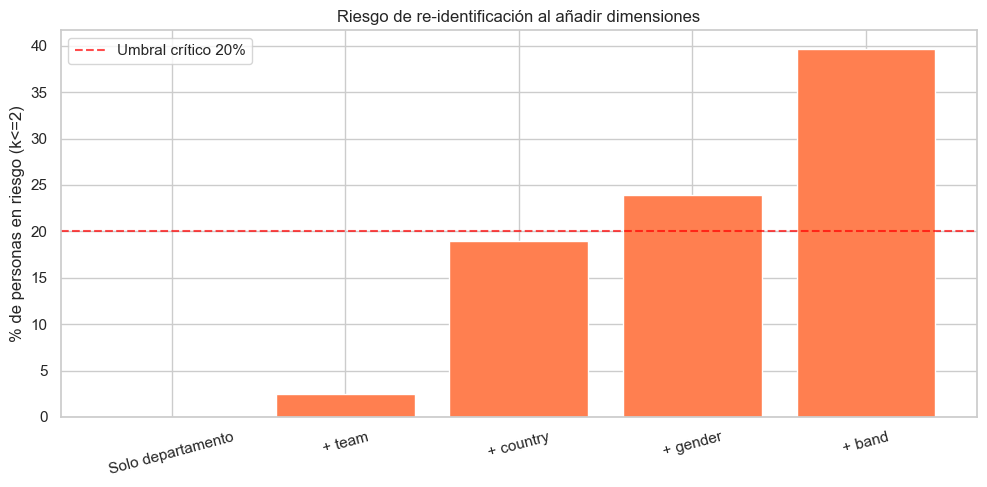


Regla práctica: nunca publicar métricas de grupos con menos de 5 personas.
En Vertex AI: garantizar que los datos de entrenamiento estén agregados adecuadamente.


In [22]:
# --- K-anonimidad progresiva: cómo empeora al añadir dimensiones ---
quasi_id_levels = [
    ("department", "Solo departamento"),
    ("department, team", "+ team"),
    ("department, team, country", "+ country"),
    ("department, team, country, gender", "+ gender"),
    ("department, team, country, gender, band", "+ band"),
]

print("K-ANONIMIDAD PROGRESIVA")
print("=" * 70)
print(f"{'Quasi-IDs':<45} {'Grupos k=1':>10} {'% en riesgo':>12}")
print("-" * 70)

results = []
for cols, label in quasi_id_levels:
    sql = f"""
    WITH grps AS (
        SELECT {cols}, COUNT(*) AS gs
        FROM `{PROJECT_ID}.{SILVER}.dim_employee`
        WHERE is_active
        GROUP BY {cols}
    )
    SELECT
        COUNTIF(gs = 1) AS k1,
        SUM(IF(gs <= 2, gs, 0)) AS risk,
        SUM(gs) AS total
    FROM grps
    """
    r = client.query(sql).to_dataframe().iloc[0]
    pct = r['risk'] / r['total'] * 100 if r['total'] > 0 else 0
    print(f"  {label:<43} {r['k1']:>10} {pct:>10.1f}%")
    results.append({'label': label, 'k1': r['k1'], 'pct_risk': pct})

# Visualización
df_kanon_prog = pd.DataFrame(results)
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(df_kanon_prog['label'], df_kanon_prog['pct_risk'], color='coral')
ax.set_ylabel('% de personas en riesgo (k<=2)')
ax.set_title('Riesgo de re-identificación al añadir dimensiones')
ax.axhline(y=20, color='red', linestyle='--', alpha=0.7, label='Umbral crítico 20%')
ax.legend()
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

print("\nRegla práctica: nunca publicar métricas de grupos con menos de 5 personas.")
print("En Vertex AI: garantizar que los datos de entrenamiento estén agregados adecuadamente.")

### 6.6 Proxy discrimination — Correlación con categorías protegidas

In [23]:
# --- Proxy discrimination en datos reales ---
sql_proxy = f"""
SELECT
    employee_code,
    gender,
    gross_salary_annual,
    tenure_months,
    global_grade,
    tier,
    stock_options,
    CASE WHEN band IN ('P1') THEN 1
         WHEN band IN ('P2') THEN 2
         WHEN band IN ('P3') THEN 3
         WHEN band IN ('E1') THEN 4
         WHEN band IN ('E2') THEN 5
         WHEN band IN ('M2') THEN 6
         WHEN band IN ('M3') THEN 7
         ELSE NULL
    END AS band_numeric
FROM `{PROJECT_ID}.{GOLD}.compensation_analysis`
WHERE gender IS NOT NULL
"""
df_proxy = client.query(sql_proxy).to_dataframe()

if not df_proxy.empty:
    from scipy import stats

    df_proxy['gender_bin'] = (df_proxy['gender'] == 'female').astype(int)

    print("ANÁLISIS DE PROXY DISCRIMINATION")
    print("=" * 65)
    print(f"{'Variable':<25} {'Correlación':>12} {'p-value':>10} {'Riesgo':>15}")
    print("-" * 65)

    for var in ['gross_salary_annual', 'tenure_months', 'global_grade', 'tier', 'stock_options', 'band_numeric']:
        valid = df_proxy[[var, 'gender_bin']].dropna()
        if len(valid) > 5:
            corr, p = stats.pointbiserialr(valid['gender_bin'], valid[var])
            risk = 'ALTO' if abs(corr) > 0.15 else 'Medio' if abs(corr) > 0.05 else 'Bajo'
            print(f"  {var:<23} {corr:>12.3f} {p:>10.4f} {risk:>15}")

    print(f"\nVariables con alta correlación con género son proxies potenciales.")
    print(f"Si las usas en un modelo predictivo, podrías discriminar indirectamente.")
    print(f"Esto es lo que regula el Art. 22 GDPR y los principios de fairness en ML.")

ANÁLISIS DE PROXY DISCRIMINATION
Variable                   Correlación    p-value          Riesgo
-----------------------------------------------------------------
  gross_salary_annual            0.066     0.4708           Medio
  tenure_months                 -0.175     0.0546            ALTO
  global_grade                  -0.231     0.0227            ALTO
  tier                          -0.249     0.0060            ALTO
  stock_options                 -0.301     0.0008            ALTO
  band_numeric                  -0.250     0.0145            ALTO

Variables con alta correlación con género son proxies potenciales.
Si las usas en un modelo predictivo, podrías discriminar indirectamente.
Esto es lo que regula el Art. 22 GDPR y los principios de fairness en ML.


---
## 7. Resumen de la arquitectura creada

En esta sesión hemos construido una arquitectura completa de datos en BigQuery:

In [24]:
# --- Inventario final ---
print("ARQUITECTURA MEDALLION EN BIGQUERY")
print("=" * 70)

for dataset_id in ["bronze_personio", "silver_personio", "gold_people_analytics", "ml_features"]:
    full_id = f"{PROJECT_ID}.{dataset_id}"
    print(f"\n  {dataset_id}:")
    try:
        tables = list(client.list_tables(full_id))
        if tables:
            for t in tables:
                table = client.get_table(t.reference)
                partition = f" | partition: {table.time_partitioning.field}" if table.time_partitioning else ""
                cluster = f" | cluster: {', '.join(table.clustering_fields)}" if table.clustering_fields else ""
                print(f"    - {t.table_id}: {table.num_rows} filas, {len(table.schema)} cols{partition}{cluster}")
        else:
            print(f"    (vacío — se poblará en sesiones posteriores)")
    except Exception:
        print(f"    (vacío)")

print(f"\n{'=' * 70}")
print(f"Todos los datos accesibles desde:")
print(f"  - BigQuery Console (SQL)")
print(f"  - Vertex AI Workbench (este notebook)")
print(f"  - Looker Studio / Connected Sheets (RRHH)")
print(f"  - BQML / Vertex AI AutoML (modelos ML)")

ARQUITECTURA MEDALLION EN BIGQUERY

  bronze_personio:
    - raw_employee_data: 209 filas, 117 cols
    - raw_employee_history: 1189 filas, 79 cols
    - raw_gross_salary: 994 filas, 109 cols

  silver_personio:
    - dim_employee: 209 filas, 51 cols
    - fact_payroll_monthly: 994 filas, 41 cols | partition: payroll_date | cluster: employee_code, legal_entity, country
    - fact_salary_history: 1189 filas, 33 cols | partition: snapshot_date | cluster: employee_code, department

  gold_people_analytics:
    - compensation_analysis: 121 filas, 19 cols
    - headcount_monthly: 317 filas, 14 cols
    - turnover_metrics: 209 filas, 18 cols

  ml_features:
    (vacío — se poblará en sesiones posteriores)

Todos los datos accesibles desde:
  - BigQuery Console (SQL)
  - Vertex AI Workbench (este notebook)
  - Looker Studio / Connected Sheets (RRHH)
  - BQML / Vertex AI AutoML (modelos ML)


---
## 8. Siguientes pasos

### Lo que hemos hecho en esta sesión:
1. **Entorno híbrido** — notebook que funciona en Vertex AI y en local
2. **Datasets organizados** en BigQuery con arquitectura Medallion
3. **Bronze** — ingesta de datos reales (Personio, histórico, nómina)
4. **Silver** — limpieza, tipado, normalización, modelo dimensional
5. **Gold** — métricas de headcount, compensación y rotación
6. **Análisis PA** — brecha salarial, compa-ratio, k-anonimidad, proxy discrimination

### Ideas clave:
- Con **209 empleados** el riesgo de re-identificación es mucho mayor que con datos sintéticos
- La **brecha salarial bruta** no es concluyente — hay que controlar por band, tenure y país
- El **compa-ratio** es la métrica correcta para evaluar equidad dentro de cada banda
- Las **proxy variables** (tenure, stock options, band) pueden correlacionar con género
- Los datos ya están en BigQuery y listos para **Vertex AI, BQML y Looker Studio**

### En las próximas sesiones:
- **Sesión 2**: Ingesta con Pub/Sub + pipelines event-driven (Eventarc)
- **Sesión 3**: Orquestación (Workflows vs Composer) + BigQuery avanzado
- **Sesión 4**: SQL avanzado sobre estos datos + Dataform como capa de transformación
- **Sesión 9**: Vertex AI — modelo de predicción de rotación sobre `ml_features`